In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load data
df = pd.read_parquet(
    "../../01_original_data/zillow/Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.parquet",
    engine="pyarrow",
)

Shape: (26314, 316)
Columns: Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'State', 'City', 'Metro', 'CountyName', '2000-01-31', '2000-02-29',
       '2000-03-31', '2000-04-30', '2000-05-31', '2000-06-30'],
      dtype='object') ...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26314 entries, 0 to 26313
Columns: 316 entries, RegionID to 2025-07-31
dtypes: float64(307), int64(3), object(6)
memory usage: 63.4+ MB
None
RegionID          0
SizeRank          0
RegionName        0
RegionType        0
StateName         0
State             0
City           1042
Metro          4732
CountyName        0
2000-01-31    13421
2000-02-29    13355
2000-03-31    13341
2000-04-30    13322
2000-05-31    13259
2000-06-30    13248
2000-07-31    13232
2000-08-31    13207
2000-09-30    13192
2000-10-31    13179
2000-11-30    13159
dtype: int64


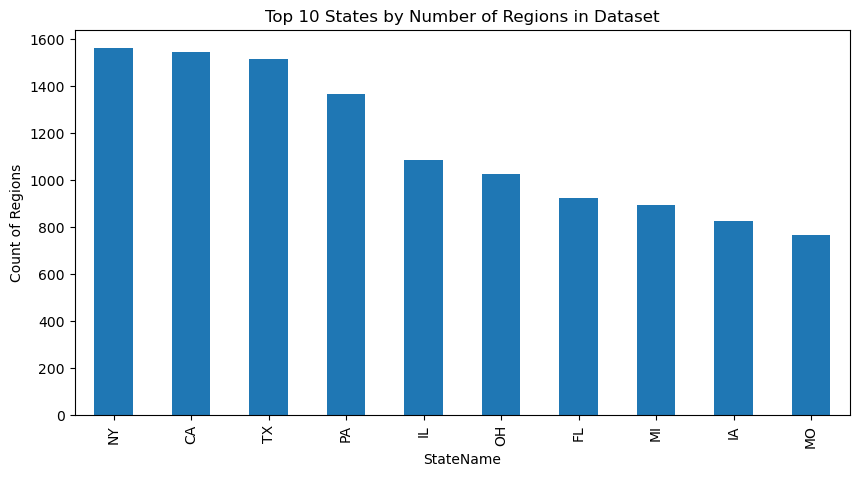

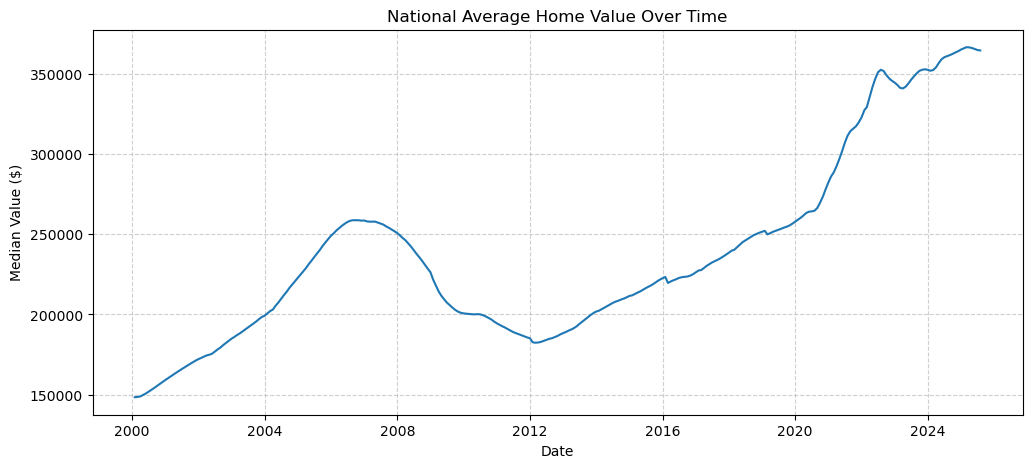

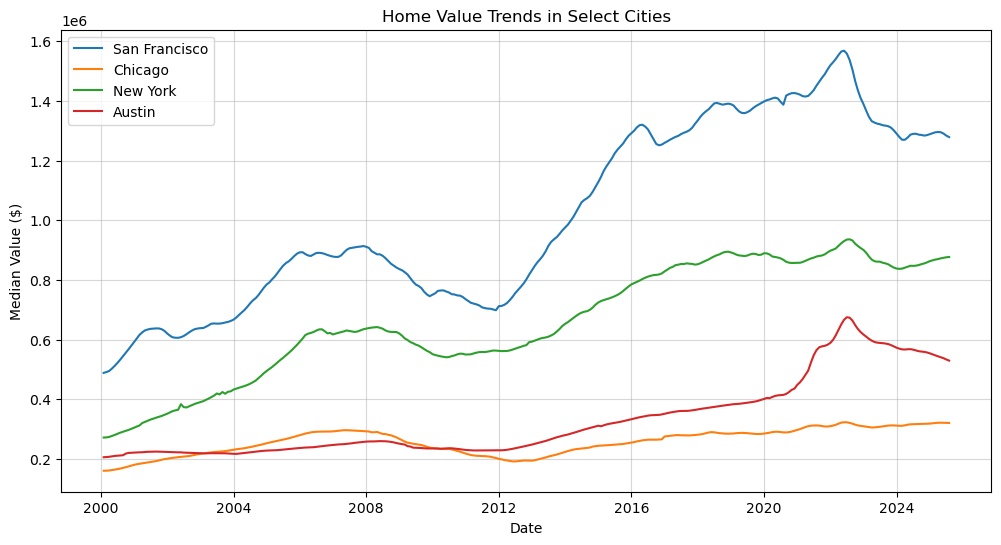

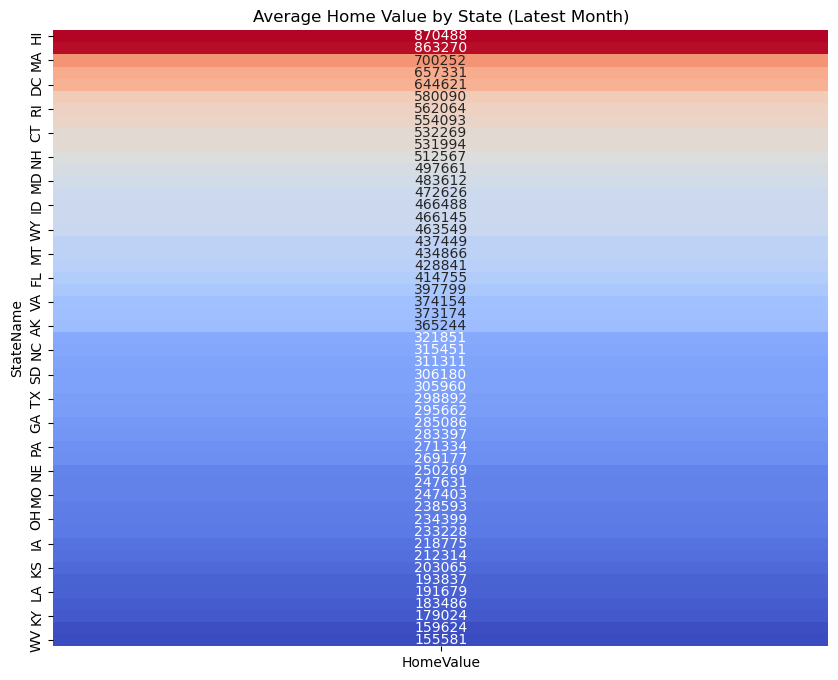

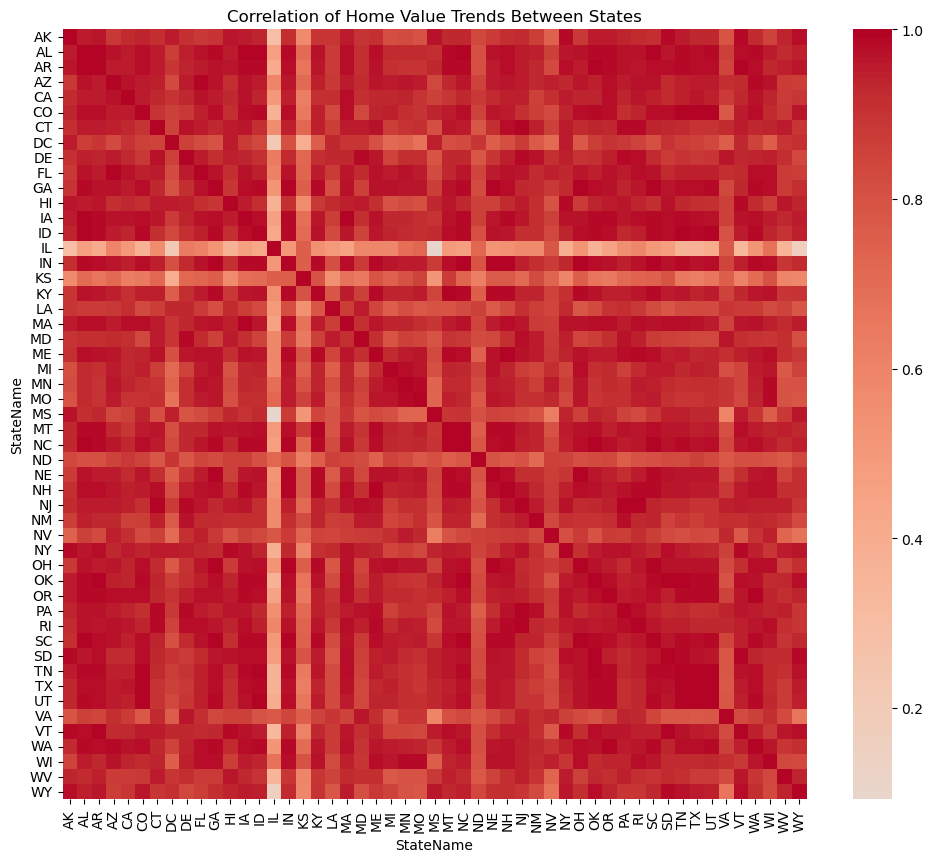

In [ ]:
# ===============================
# 1. Basic Checks
# ===============================
print("Shape:", df.shape)
print("Columns:", df.columns[:15], "...")  # preview first 15 columns
print(df.info())
print(df.isna().sum().head(20))  # missing values in first 20 columns

# ===============================
# 2. Location Distribution
# ===============================
plt.figure(figsize=(10, 5))
df["StateName"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 States by Number of Regions in Dataset")
plt.ylabel("Count of Regions")
plt.show()

# ===============================
# 3. Reshape to Long Format for Time Series
# ===============================
id_vars = [
    "RegionID",
    "SizeRank",
    "RegionName",
    "RegionType",
    "StateName",
    "State",
    "City",
    "Metro",
    "CountyName",
]
df_long = df.melt(id_vars=id_vars, var_name="Date", value_name="HomeValue")

# Convert Date
df_long["Date"] = pd.to_datetime(df_long["Date"], errors="coerce")

# Drop missing
df_long = df_long.dropna(subset=["HomeValue"])

# ===============================
# 4. National Trend Over Time
# ===============================
national_trend = df_long.groupby("Date")["HomeValue"].mean()

plt.figure(figsize=(12, 5))
plt.plot(national_trend.index, national_trend.values)
plt.title("National Average Home Value Over Time")
plt.ylabel("Median Value ($)")
plt.xlabel("Date")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ===============================
# 5. Example City Trends
# ===============================
example_cities = ["San Francisco", "Chicago", "New York", "Austin"]
plt.figure(figsize=(12, 6))
for city in example_cities:
    city_data = df_long[df_long["City"] == city].groupby("Date")["HomeValue"].mean()
    plt.plot(city_data.index, city_data.values, label=city)

plt.legend()
plt.title("Home Value Trends in Select Cities")
plt.ylabel("Median Value ($)")
plt.xlabel("Date")
plt.grid(True, alpha=0.5)
plt.show()

# ===============================
# 6. Heatmap of State Averages in 2025
# ===============================
latest = df_long[df_long["Date"] == df_long["Date"].max()]
state_avg = latest.groupby("StateName")["HomeValue"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(state_avg.to_frame(), annot=True, fmt=".0f", cmap="coolwarm", cbar=False)
plt.title("Average Home Value by State (Latest Month)")
plt.show()

# ===============================
# 7. Correlation Across Time (Trend Similarity)
# ===============================
# Pick a few states and compare correlations
pivot_state = df_long.groupby(["Date", "StateName"])["HomeValue"].mean().reset_index()
pivot_state = pivot_state.pivot(index="Date", columns="StateName", values="HomeValue")

corr = pivot_state.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation of Home Value Trends Between States")
plt.show()